# Sales Analytics Data Science Challenge

In [22]:
!pip install xgboost

In [28]:
#############################
# 1. IMPORT LIBRARIES
#############################
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_squared_error, r2_score, 
                             accuracy_score, classification_report,
                             confusion_matrix)

# Time Series & Stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# Clustering
from sklearn.cluster import KMeans

# Statistical tests
from scipy.stats import spearmanr

### 1. DATA LOADING & CLEANING

* Check for missing or incorrect values. If data appears incomplete for some reps or leads, investigate or remove/impute those rows.
* Ensure date fields, user identifiers, or any relevant IDs are correct and consistent.


In [29]:
df = pd.read_csv("/Users/softwareengineer/Desktop/datascience/data-science-challenge/data/monthly_report_expanded.csv")

# Convert column names to lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(" ", "_")

print("Data Info:")
df.info()

print("\nData Description:")
print(df.describe())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values per column:")
print(df.isna().sum())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 31 columns):
 #   Column                                                      Non-Null Count  Dtype 
---  ------                                                      --------------  ----- 
 0   user_name                                                   50 non-null     object
 1   outbound_calls_(last_month)                                 50 non-null     int64 
 2   personalized_outbound_emails_(last_month)                   50 non-null     int64 
 3   calls_with_correct_contact_(last_month)                     50 non-null     int64 
 4   demo_meeting_set_(last_month)                               50 non-null     int64 
 5   demo_meeting_completed_(last_month)                         50 non-null     int64 
 6   opportunity_created_(last_month)                            50 non-null     int64 
 7   1:1_(last_month)                                            50 non-null     int64 
 8   c

## 3. EXPLORATORY DATA ANALYSIS

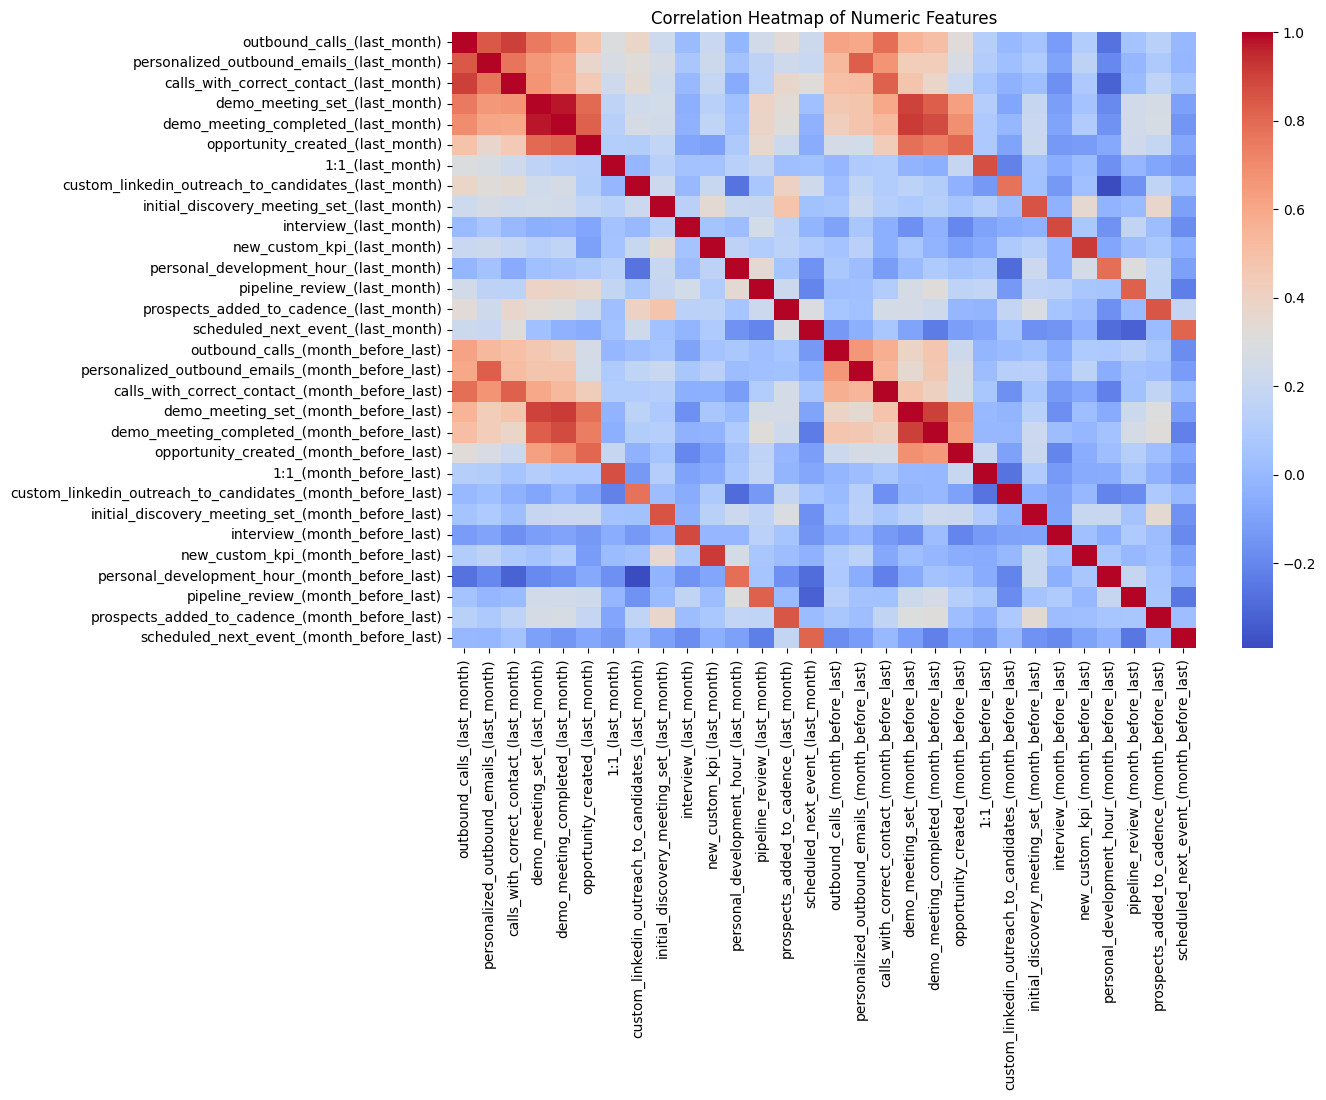

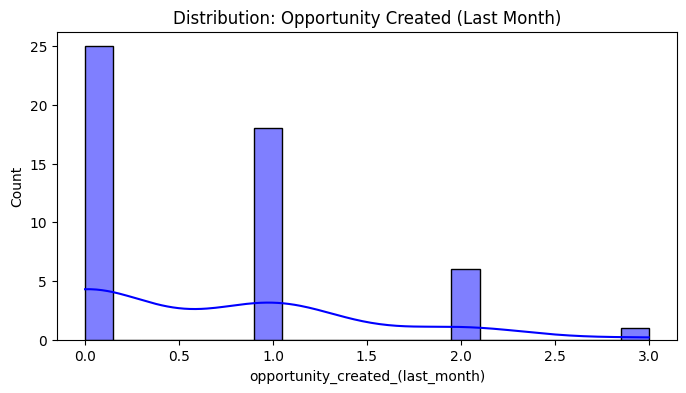

In [30]:
# CORRELATION HEATMAP (numeric only)
numeric_df = df.select_dtypes(include=[np.number])  # Only numeric columns
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# DISTRIBUTION OF 'opportunity_created_(last_month)'
plt.figure(figsize=(8,4))
sns.histplot(df['opportunity_created_(last_month)'], bins=20, kde=True, color='blue')
plt.title("Distribution: Opportunity Created (Last Month)")
plt.show()

## 4. FEATURE ENGINEERING

Feature Engineering
* Aggregation of Activities: You currently have last month vs. month-before-last data. Consider generating additional time-based features (e.g., 3-month average, rate of change, rolling averages, etc.).
* Ratios and Derived Features: For instance, “calls with correct contact” ÷ “outbound calls” could represent call quality. Another example might be “demo meeting completed” ÷ “demo meeting set” to measure close ratio for demos.
* Lag Features: If you collect multiple months, build lag features (e.g., how last month’s activities might influence this month’s outcomes).

In [31]:
# Example ratio feature
df['call_to_correct_contact_ratio'] = np.where(
    df['outbound_calls_(last_month)'] > 0, 
    df['calls_with_correct_contact_(last_month)'] / df['outbound_calls_(last_month)'],
    0
)

# Growth feature from last month to prior month
df['opportunity_growth'] = (
    df['opportunity_created_(last_month)'] - 
    df['opportunity_created_(month_before_last)']
)

## 5. PREDICTIVE MODELING (Regression)
### Forecast Next Month's Opportunity Creation

In [32]:
# 5A.1. Define target and features
target_col = 'opportunity_created_(last_month)'
exclude_cols = ['user_name', target_col]  # user_name is non-numeric ID, plus target
X = df.drop(columns=exclude_cols)
y = df[target_col]

# 5A.2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5A.3. Scaling (Optional for tree-based but generally good practice)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5A.4. Random Forest Regressor + GridSearchCV
rf_reg = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
}

grid_search = GridSearchCV(rf_reg, param_grid, cv=3, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)
best_rf_reg = grid_search.best_estimator_

print("\nBest RandomForestRegressor Params:", grid_search.best_params_)

# 5A.5. Evaluate on Test Set
y_pred_reg = best_rf_reg.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_reg)

print(f"\nRegression Model Performance:")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test R^2: {r2:.2f}")

# 5A.6. Feature Importances
importances = best_rf_reg.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Feature Importances:")
print(feature_importance_df.head(10))


Best RandomForestRegressor Params: {'max_depth': None, 'n_estimators': 50}

Regression Model Performance:
Test RMSE: 0.72
Test R^2: 0.46

Top 10 Feature Importances:
                                              Feature  Importance
3                       demo_meeting_set_(last_month)    0.288956
4                 demo_meeting_completed_(last_month)    0.192213
30                                 opportunity_growth    0.116632
17               demo_meeting_set_(month_before_last)    0.109031
19            opportunity_created_(month_before_last)    0.104866
18         demo_meeting_completed_(month_before_last)    0.064566
29                      call_to_correct_contact_ratio    0.026140
24                 new_custom_kpi_(month_before_last)    0.012316
20                            1:1_(month_before_last)    0.011755
22  initial_discovery_meeting_set_(month_before_last)    0.008842


## 6. LEAD SCORING MODEL (Classification)


Lead Scoring Model Accuracy: 0.80
Classification Report:
              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       1.00      0.71      0.83         7

    accuracy                           0.80        10
   macro avg       0.80      0.86      0.79        10
weighted avg       0.88      0.80      0.81        10



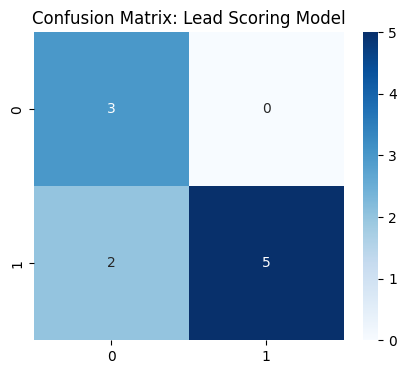

In [33]:
# Define a binary outcome: did the rep create at least 1 opportunity last month?
df['had_opportunity'] = (df['opportunity_created_(last_month)'] > 0).astype(int)

X_class = df.drop(columns=['user_name', target_col, 'had_opportunity'])
y_class = df['had_opportunity']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

# Scale (if desired)
Xc_train_scaled = scaler.fit_transform(Xc_train)
Xc_test_scaled = scaler.transform(Xc_test)

# Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(Xc_train_scaled, yc_train)

# Evaluate Classifier
yc_pred = rf_clf.predict(Xc_test_scaled)
acc = accuracy_score(yc_test, yc_pred)
print(f"\nLead Scoring Model Accuracy: {acc:.2f}")
print("Classification Report:")
print(classification_report(yc_test, yc_pred))

# Confusion Matrix
cm = confusion_matrix(yc_test, yc_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix: Lead Scoring Model")
plt.show()

## 7. IDENTIFY AT-RISK SALES REPS (Clustering)

In [12]:
df_cluster = df.drop(columns=['user_name'])  # or select only relevant numeric features
scaled_features = StandardScaler().fit_transform(df_cluster.select_dtypes(include=[np.number]))

kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster_label'] = kmeans.fit_predict(scaled_features)

# Suppose cluster 1 is "at-risk"
at_risk_reps = df.loc[df['cluster_label'] == 1, 'user_name']
print("\nPotentially At-Risk Sales Reps:")
print(at_risk_reps.to_list())


Potentially At-Risk Sales Reps:
['John Smith', 'Maria Garcia', 'Alex Johnson', 'Raj Patel', 'Fatima Ahmed', 'Sean Murphy', 'Maya Patel', 'Zara Ali', 'Andre Silva', 'Mia Rodriguez', 'Benjamin Lee', 'Christopher Davis']


## 8. BASIC CORRELATION & CAUSAL-STYLE ANALYSIS

In [13]:
# 8A. Correlation with Opportunity Creation
df_numeric = df.select_dtypes(include=[np.number])
corr_with_target = df_numeric.corr()['opportunity_created_(last_month)'].sort_values(ascending=False)
print("\nCorrelation with Opportunity Created (Last Month):")
print(corr_with_target.head(10))

# 8B. Spearman correlation for Personal Development Hours
spearman_corr, p_value = spearmanr(df['personal_development_hour_(last_month)'],
                                   df['opportunity_created_(last_month)'])
print(f"\nSpearman Correlation (Dev Hours vs. Opportunity Creation): {spearman_corr:.2f}")
print(f"P-value: {p_value:.4f}")


Correlation with Opportunity Created (Last Month):
opportunity_created_(last_month)              1.000000
had_opportunity                               0.863354
demo_meeting_completed_(last_month)           0.821902
opportunity_created_(month_before_last)       0.805772
demo_meeting_set_(last_month)                 0.801532
demo_meeting_set_(month_before_last)          0.780485
cluster_label                                 0.739996
demo_meeting_completed_(month_before_last)    0.739506
outbound_calls_(last_month)                   0.486002
calls_with_correct_contact_(last_month)       0.448390
Name: opportunity_created_(last_month), dtype: float64

Spearman Correlation (Dev Hours vs. Opportunity Creation): 0.08
P-value: 0.5847


## 9. TIME SERIES ANALYSIS

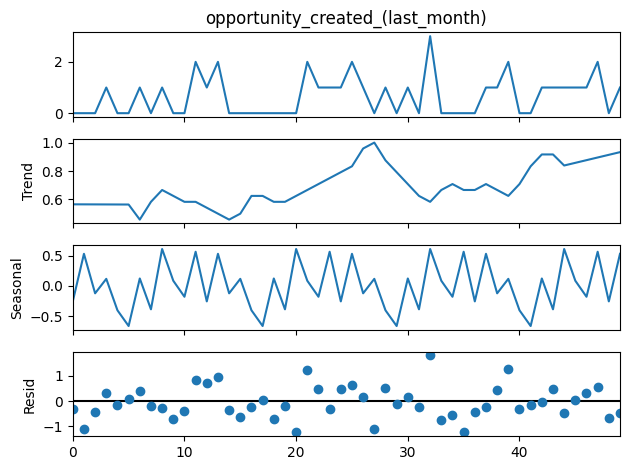


ARIMA Forecast for Next 1 Month: [0.75049468]


In [14]:
# For demonstration, treat each row as a consecutive time point.
ts_data = df['opportunity_created_(last_month)']

# Seasonal Decomposition
result = seasonal_decompose(ts_data, period=12, model='additive', extrapolate_trend='freq')
result.plot()
plt.show()

# ARIMA Forecast (1-step)
model = ARIMA(ts_data, order=(1,1,1))
model_fit = model.fit()
forecast = model_fit.forecast(steps=1)
print("\nARIMA Forecast for Next 1 Month:", forecast.values)

## 10. PRESCRIPTIVE ANALYTICS

In [15]:
# Simple Recommendation: Increase calls by 10% if below median
call_median = df['outbound_calls_(last_month)'].median()
df['recommended_calls'] = df['outbound_calls_(last_month)'].apply(
    lambda x: x * 1.1 if x < call_median else x
)

print("\nSample of Prescriptive Recommendations (Calls):")
print(df[['user_name', 'outbound_calls_(last_month)', 'recommended_calls']].head(10))


Sample of Prescriptive Recommendations (Calls):
         user_name  outbound_calls_(last_month)  recommended_calls
0      Emma Wilson                          134              147.4
1      Marcus Chen                          309              309.0
2      Sarah Patel                          135              148.5
3  James Rodriguez                          196              215.6
4       Aisha Khan                          138              151.8
5  Michael O'Brien                           83               91.3
6      Priya Singh                          198              217.8
7        David Kim                          257              257.0
8     Rachel Cohen                          149              163.9
9    Thomas Nguyen                          288              288.0


## 11. CONCLUSION & KEY INSIGHTS

In [16]:
# Display results
print(f"""
Key Insights & Recommendations:
1. Random Forest Regression Model R^2: {r2:.2f}
   - Top features for predicting opportunity creation are shown in 'feature_importance_df'.
2. Lead Scoring Classifier Accuracy: {acc:.2f}
   - Helps prioritize which reps/prospects are most likely to create opportunities.
3. Cluster Analysis identifies an 'at-risk' group of reps (cluster_label = 1)
   for potential additional coaching or support.
4. Spearman correlation indicates Personal Development Hours are positively
   associated with opportunity creation.
5. Time-series analysis (seasonal decomposition, ARIMA) provides a 1-month forecast
   of total opportunities, suggesting resource planning strategies.
6. Prescriptive analytics: encouraging reps who are below the median calls
   to increase outbound calls by ~10% could yield improved results.

Actionable Steps:
- Implement recommended daily call targets for reps below median call volume.
- Monitor the 'at-risk' cluster more closely; provide extra coaching/training.
- Consider increasing personal development hours or focusing them more effectively
  given their positive correlation with opportunities.
- Use the ARIMA forecast to anticipate peaks and troughs in sales activity.
""")


Key Insights & Recommendations:
1. Random Forest Regression Model R^2: 0.46
   - Top features for predicting opportunity creation are shown in 'feature_importance_df'.
2. Lead Scoring Classifier Accuracy: 0.80
   - Helps prioritize which reps/prospects are most likely to create opportunities.
3. Cluster Analysis identifies an 'at-risk' group of reps (cluster_label = 1)
   for potential additional coaching or support.
4. Spearman correlation indicates Personal Development Hours are positively
   associated with opportunity creation.
5. Time-series analysis (seasonal decomposition, ARIMA) provides a 1-month forecast
   of total opportunities, suggesting resource planning strategies.
6. Prescriptive analytics: encouraging reps who are below the median calls
   to increase outbound calls by ~10% could yield improved results.

Actionable Steps:
- Implement recommended daily call targets for reps below median call volume.
- Monitor the 'at-risk' cluster more closely; provide extra coaching/